# Full Pipeline Accuracy Review

This notebook ingests the artifacts produced by `scripts/run_full_pipeline_llama_unlearn.sh` and reports the accuracies for every LLaMA/Qwen training regime.

* **Section 1** loads every `eval_result/accuracies_ckpts*.json` blob and validates that the expected checkpoints produced metrics.
* **Section 2** renders human-readable comparison tables for each model family (global + per-client).
* **Section 3** visualizes the same comparisons, grouped by benchmark.

Run each cell from the root of the FederatedScope checkout so that relative paths resolve correctly.

## 1. Data ingestion and formatting

In [128]:
import json
import re
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.options.display.float_format = '{:,.4f}'.format

In [129]:
FS_ROOT = Path.cwd()
PIPELINE_SCRIPT = FS_ROOT / "scripts" / "run_full_pipeline_llama_unlearn.sh"
EVAL_DIR = FS_ROOT / "eval_result"
RESULTS_DIR = FS_ROOT / "results_full"
LOG_DIR = FS_ROOT / "logs"

print(f"Repo root        : {FS_ROOT}")
print(f"Pipeline script  : {PIPELINE_SCRIPT}")
print(f"Eval artifacts   : {EVAL_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Logs directory   : {LOG_DIR}")

for path, desc in [
    (PIPELINE_SCRIPT, "pipeline script"),
    (EVAL_DIR, "eval_result directory"),
    (RESULTS_DIR, "results_full directory"),
    (LOG_DIR, "logs directory"),
]:
    if not path.exists():
        raise FileNotFoundError(f"Missing {desc}: {path}")

Repo root        : /storage/ice1/7/0/sbhansali8/FederatedScope
Pipeline script  : /storage/ice1/7/0/sbhansali8/FederatedScope/scripts/run_full_pipeline_llama_unlearn.sh
Eval artifacts   : /storage/ice1/7/0/sbhansali8/FederatedScope/eval_result
Results directory: /storage/ice1/7/0/sbhansali8/FederatedScope/results_full
Logs directory   : /storage/ice1/7/0/sbhansali8/FederatedScope/logs


In [130]:

MODEL_DIR_TO_KEY = {
    'llama2': 'llama2_composite_meta3',
    'llama2_unlearn': 'llama2_composite_meta3_unlearn',
    'llama2_unlearn_shrink05': 'llama2_composite_meta3_unlearn_shrink05',
    'llama2_unlearn_loo': 'llama2_composite_meta3_unlearn_loo',
    'llama2_unlearn_loo_shrink05': 'llama2_composite_meta3_unlearn_loo_shrink05',
    'qwen_moe': 'qwen15moe_composite_meta3',
    'qwen15moe': 'qwen15moe_composite_meta3',
    'qwen15moe_unlearn': 'qwen15moe_composite_meta3_unlearn',
    'qwen15moe_unlearn_shrink05': 'qwen15moe_composite_meta3_unlearn_shrink05'
}

BENCHMARK_NORMALIZATION = {
    'all_in_one': 'mmlu',
    'interleaved_all_in_one': 'mmlu',
    'gsm8k_local': 'gsm8k',
    'gsm8k': 'gsm8k',
    'code_local': 'code',
    'code': 'code',
    'instr_local': 'mmlu',
    'mmlu': 'mmlu',
    None: 'mmlu',
    '': 'mmlu'
}

BENCHMARK_LABELS = {
    'mmlu': 'MMLU',
    'gsm8k': 'GSM8K',
    'code': 'Code'
}

SINGLE_TASK_BASELINE_TARGETS = {
    'code_local': 'code',
    'gsm8k_local': 'gsm8k',
    'instr_local': 'mmlu'
}

BASELINE_BENCHMARK_SUFFIXES = [
    'interleaved_all_in_one',
    'all_in_one',
    'instr_local',
    'gsm8k_local',
    'code_local'
]

FAMILY_LABELS = {
    'llama2': 'LLaMA 2',
    'llama2_composite_meta3': 'LLaMA 2',
    'llama2_composite_meta3_unlearn': 'LLaMA 2',
    'llama2_composite_meta3_unlearn_shrink05': 'LLaMA 2',
    'llama2_composite_meta3_unlearn_loo': 'LLaMA 2',
    'llama2_composite_meta3_unlearn_loo_shrink05': 'LLaMA 2',
    'qwen_moe': 'Qwen 1.5 MoE',
    'qwen15moe': 'Qwen 1.5 MoE',
    'qwen15moe_composite_meta3': 'Qwen 1.5 MoE',
    'qwen15moe_composite_meta3_unlearn': 'Qwen 1.5 MoE',
    'qwen15moe_composite_meta3_unlearn_shrink05': 'Qwen 1.5 MoE'
}

FAMILY_BENCHMARKS = {
    'LLaMA 2': ['mmlu', 'gsm8k', 'code'],
    'Qwen 1.5 MoE': ['mmlu', 'gsm8k', 'code']
}

CLIENT_IDS = ['client_1', 'client_2', 'client_3']
CLIENT_TITLES = [f"Client {cid.split('_')[-1]}" for cid in CLIENT_IDS]

GLOBAL_COLUMN_SPECS = [
    ('Global · Baseline (Code only)', {'scope': 'baseline', 'benchmark_raw': 'code_local'}),
    ('Global · Baseline (GSM8K only)', {'scope': 'baseline', 'benchmark_raw': 'gsm8k_local'}),
    ('Global · Baseline (Instruction only)', {'scope': 'baseline', 'benchmark_raw': 'instr_local'}),
    ('Global · Baseline (All-in-one)', {'scope': 'baseline', 'benchmark_raw': 'all_in_one'}),
    ('Global · Baseline (Interleaved)', {'scope': 'baseline', 'benchmark_raw': 'interleaved_all_in_one'}),
    ('Global · Standard FL', {'scope': 'global', 'variant': 'Standard'}),
    ('Global · Unlearn', {'scope': 'global', 'variant': 'Unlearn'}),
    ('Global · Unlearn (shrink=0.5)', {'scope': 'global', 'variant': 'Unlearn (shrink=0.5)'}),
    ('Global · Unlearn (LOO)', {'scope': 'global', 'variant': 'Unlearn (LOO)'}),
    ('Global · Unlearn (LOO, shrink=0.5)', {'scope': 'global', 'variant': 'Unlearn (LOO, shrink=0.5)'})
]

CLIENT_COLUMN_SPECS = []
for cid, title in zip(CLIENT_IDS, CLIENT_TITLES):
    CLIENT_COLUMN_SPECS.extend([
        (f"{title} · Standard", {'scope': 'client', 'variant': 'Standard', 'client': cid}),
        (f"{title} · Unlearn", {'scope': 'client', 'variant': 'Unlearn', 'client': cid}),
        (f"{title} · Unlearn (shrink=0.5)", {'scope': 'client', 'variant': 'Unlearn (shrink=0.5)', 'client': cid}),
        (f"{title} · Unlearn (LOO)", {'scope': 'client', 'variant': 'Unlearn (LOO)', 'client': cid}),
        (f"{title} · Unlearn (LOO, shrink=0.5)", {'scope': 'client', 'variant': 'Unlearn (LOO, shrink=0.5)', 'client': cid}),
    ])

CATEGORY_ORDER = ['STEM', 'humanities', 'social sciences', 'other (business, health, misc.)']


In [131]:
def infer_family(model_key: str) -> str:
    for token, label in FAMILY_LABELS.items():
        if model_key.startswith(token):
            return label
    return model_key


def infer_variant(model_key: str, scope: str, benchmark: Optional[str], client: Optional[str]) -> str:
    if scope == 'baseline':
        if benchmark == 'all_in_one':
            return 'Baseline (All-in-one)'
        if benchmark == 'interleaved_all_in_one':
            return 'Baseline (Interleaved)'
        label = benchmark.replace('_', ' ').title() if benchmark else 'Baseline'
        return f'Baseline ({label})'
    if scope == 'client':
        if 'unlearn_loo_shrink05' in model_key:
            return 'Unlearn (LOO, shrink=0.5)'
        if 'unlearn_loo' in model_key:
            return 'Unlearn (LOO)'
        if 'unlearn_shrink05' in model_key:
            return 'Unlearn (shrink=0.5)'
        if 'unlearn' in model_key:
            return 'Unlearn'
        return 'Standard'
    if 'unlearn_loo_shrink05' in model_key:
        return 'Unlearn (LOO, shrink=0.5)'
    if 'unlearn_loo' in model_key:
        return 'Unlearn (LOO)'
    if 'unlearn_shrink05' in model_key:
        return 'Unlearn (shrink=0.5)'
    if 'unlearn' in model_key:
        return 'Unlearn'
    return 'Standard'


def parse_accuracy_file(path: Path) -> dict:
    filename = path.name
    if not filename.startswith('accuracies_') or not filename.endswith('.json'):
        return None
    core = filename[len('accuracies_'):-5]
    benchmark_override = None
    if '__' in core:
        core, benchmark_override = core.rsplit('__', 1)
    if core.startswith('ckpts_'):
        core = core[len('ckpts_'):]
    if core.endswith('.ckpt'):
        core = core[:-5]

    raw_name = core
    scale = 'full' if raw_name.startswith('full_') else 'default'
    descriptor = raw_name[5:] if scale == 'full' else raw_name

    scope = 'global'
    model_key = descriptor
    benchmark = benchmark_override
    eval_benchmark = benchmark_override
    client = None
    lookup_key = model_key

    if descriptor.startswith('baselines_'):
        scope = 'baseline'
        rest = descriptor[len('baselines_'):]
        matched_suffix = None
        for suffix in BASELINE_BENCHMARK_SUFFIXES:
            token = f'_{suffix}'
            if rest.endswith(token):
                matched_suffix = suffix
                model_key = rest[:-len(token)]
                break
        if matched_suffix is None:
            parts = rest.split('_', 1)
            model_key = parts[0]
            matched_suffix = parts[1] if len(parts) > 1 else benchmark_override
        benchmark = matched_suffix
        lookup_key = model_key
    elif '_clients_' in descriptor:
        scope = 'client'
        model_key, client_part = descriptor.split('_clients_', 1)
        match = re.search(r'client_(\d+)', client_part)
        client = f"client_{match.group(1)}" if match else client_part
        lookup_key = model_key

    family = infer_family(model_key)
    variant = infer_variant(model_key, scope, benchmark, client)

    eval_benchmark = eval_benchmark or benchmark

    record = {
        'file': str(path.relative_to(FS_ROOT)),
        'raw_name': raw_name,
        'scale': scale,
        'scope': scope,
        'model_key': model_key,
        'lookup_key': lookup_key,
        'model_family': family,
        'variant': variant,
        'benchmark': benchmark,
        'benchmark_eval': eval_benchmark,
        'client': client,
        'weighted_accuracy': None,
        'categories': {},
        'subcategories': {},
    }

    try:
        with path.open() as f:
            payload = json.load(f)
        record['weighted_accuracy'] = payload.get('weighted_accuracy')
        record['categories'] = payload.get('categories', {})
        record['subcategories'] = payload.get('subcategories', {})
    except json.JSONDecodeError as exc:
        print(f"Skipping {path}: {exc}")
        return None

    if record['benchmark'] is None:
        record['benchmark'] = ''
    if record['benchmark_eval'] is None:
        record['benchmark_eval'] = ''

    record['match_key'] = (
        record['scope'],
        record['scale'],
        record['lookup_key'],
        record['benchmark'],
        record['client'] or ''
    )
    return record

records = []
for accuracy_path in sorted(EVAL_DIR.glob('accuracies_ckpts*.json')):
    record = parse_accuracy_file(accuracy_path)
    if record is not None:
        records.append(record)

if not records:
    raise RuntimeError('No accuracy files were found – rerun the evaluations.')

records_df = pd.DataFrame(records)
records_df['benchmark_eval'] = records_df['benchmark_eval'].fillna('')
records_df['benchmark_norm'] = records_df['benchmark_eval'].map(
    lambda key: BENCHMARK_NORMALIZATION.get(key, 'mmlu')
)
category_columns = sorted({k for rec in records for k in rec['categories'].keys()})
for col in category_columns:
    records_df[col] = records_df['categories'].apply(lambda d: d.get(col))

records_df = records_df.sort_values(by=['scope', 'model_family', 'variant']).reset_index(drop=True)
print(f"Loaded {len(records_df)} accuracy artifacts.")
display(records_df.head())

Loaded 126 accuracy artifacts.


,file,raw_name,scale,scope,model_key,lookup_key,model_family,variant,benchmark,benchmark_eval,client,weighted_accuracy,categories,subcategories,match_key,benchmark_norm,STEM,go,gsm8k,humanities,java,javascript,"other (business, health, misc.)",php,python,ruby,social sciences
0,eval_result/accuracies_ckpts_baselines_llama2_all_in_one.ckpt.json,baselines_llama2_all_in_one,default,baseline,llama2,llama2,LLaMA 2,Baseline (All-in-one),all_in_one,all_in_one,None,0.4138,"{'STEM': 0.35321404903909875, 'humanities': 0.3534537725823592, 'social sciences': 0.4926876828079298, 'other (business, health, misc.)': 0.48272671190623073}",{},"(baseline, default, llama2, all_in_one, )",mmlu,0.3532,NaN,NaN,0.3535,NaN,NaN,0.4827,NaN,NaN,NaN,0.4927
1,eval_result/accuracies_ckpts_full_baselines_llama2_all_in_one.ckpt.json,full_baselines_llama2_all_in_one,full,baseline,llama2,llama2,LLaMA 2,Baseline (All-in-one),all_in_one,all_in_one,None,0.4116,"{'STEM': 0.36713055003313455, 'humanities': 0.3424017003188098, 'social sciences': 0.48423789405264867, 'other (business, health, misc.)': 0.4842689697717458}",{},"(baseline, full, llama2, all_in_one, )",mmlu,0.3671,NaN,NaN,0.3424,NaN,NaN,0.4843,NaN,NaN,NaN,0.4842
2,eval_result/accuracies_ckpts_full_baselines_llama2_all_in_one.ckpt__code.json,full_baselines_llama2_all_in_one,full,baseline,llama2,llama2,LLaMA 2,Baseline (All-in-one),all_in_one,code,None,0.5340,"{'python': 0.5418921356421357, 'javascript': 0.5170445781274101, 'java': 0.5313835519714594, 'ruby': 0.5436594997806056, 'php': 0.5448557641506111, 'go': 0.511440766916241}",{},"(baseline, full, llama2, all_in_one, )",code,NaN,0.5114,NaN,NaN,0.5314,0.5170,NaN,0.5449,0.5419,0.5437,NaN
3,eval_result/accuracies_ckpts_full_baselines_llama2_all_in_one.ckpt__gsm8k.json,full_baselines_llama2_all_in_one,full,baseline,llama2,llama2,LLaMA 2,Baseline (All-in-one),all_in_one,gsm8k,None,0.0705,{'gsm8k': 0.07050796057619409},{},"(baseline, full, llama2, all_in_one, )",gsm8k,NaN,NaN,0.0705,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,eval_result/accuracies_ckpts_baselines_llama2_code_local.ckpt.json,baselines_llama2_code_local,default,baseline,llama2,llama2,LLaMA 2,Baseline (Code Local),code_local,code_local,None,0.3722,"{'STEM': 0.3442677269715043, 'humanities': 0.32688629117959617, 'social sciences': 0.433539161520962, 'other (business, health, misc.)': 0.405613818630475}",{},"(baseline, default, llama2, code_local, )",code,0.3443,NaN,NaN,0.3269,NaN,NaN,0.4056,NaN,NaN,NaN,0.4335


In [132]:
expected_entries = []

for dir_name, model_key in MODEL_DIR_TO_KEY.items():
  candidate = RESULTS_DIR / 'global' / dir_name
  if candidate.exists():
    for benchmark_dir in candidate.iterdir():
      if benchmark_dir.is_dir():
        expected_entries.append({
            'scope': 'global', 'scale': 'full', 'lookup_key': model_key,
            'benchmark': benchmark_dir.name, 'client': '', 'source_path': str(benchmark_dir)
        })

clients_root = RESULTS_DIR / 'clients'
if clients_root.exists():
  for dir_name, model_key in MODEL_DIR_TO_KEY.items():
    model_dir = clients_root / dir_name
    if not model_dir.exists():
      continue
    for client_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
      expected_entries.append({
          'scope': 'client', 'scale': 'full', 'lookup_key': model_key,
          'benchmark': client_dir.name, 'client': client_dir.name, 'source_path': str(client_dir)
      })

baselines_root = RESULTS_DIR / 'baselines'
if baselines_root.exists():
  for model_dir in sorted(p for p in baselines_root.iterdir() if p.is_dir()):
    for bench_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
      expected_entries.append({
          'scope': 'baseline', 'scale': 'full', 'lookup_key': model_dir.name,
          'benchmark': bench_dir.name, 'client': '', 'source_path': str(bench_dir)
      })

expected_df = pd.DataFrame(expected_entries)
if expected_df.empty:
  print('results_full/ is empty – no expectations could be derived.')
else:
  expected_df['match_key'] = list(zip(
      expected_df['scope'], expected_df['scale'], expected_df['lookup_key'],
      expected_df['benchmark'], expected_df['client']
  ))
  have_keys = set(records_df['match_key'])
  expected_df['present'] = expected_df['match_key'].apply(lambda key: key in have_keys)
  missing_df = expected_df[~expected_df['present']].copy()
  if missing_df.empty:
    print('All expected accuracy files are present in eval_result/.')
  else:
    print('Accuracy artifacts missing from eval_result/:')
    display(missing_df[['scope', 'lookup_key', 'benchmark', 'client', 'source_path']])

Accuracy artifacts missing from eval_result/:


,scope,lookup_key,benchmark,client,source_path
1,global,llama2_composite_meta3,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/results_full/global/llama2/mmlu
4,global,llama2_composite_meta3_unlearn,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/results_full/global/llama2_unlearn/mmlu
7,global,llama2_composite_meta3_unlearn_shrink05,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/results_full/global/llama2_unlearn_shrink05/mmlu
10,global,llama2_composite_meta3_unlearn_loo,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/results_full/global/llama2_unlearn_loo/mmlu
13,global,llama2_composite_meta3_unlearn_loo_shrink05,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/results_full/global/llama2_unlearn_loo_shrink05/mmlu
16,global,qwen15moe_composite_meta3,mmlu,,/storage/ice1/7/0/sbhansali8/FederatedScope/results_full/global/qwen_moe/mmlu
17,global,qwen15moe_composite_meta3,code,,/storage/ice1/7/0/sbhansali8/FederatedScope/results_full/global/qwen_moe/code
19,global,qwen15moe_composite_meta3_unlearn,code,,/storage/ice1/7/0/sbhansali8/FederatedScope/results_full/global/qwen15moe_unlearn/code
21,global,qwen15moe_composite_meta3_unlearn_shrink05,code,,/storage/ice1/7/0/sbhansali8/FederatedScope/results_full/global/qwen15moe_unlearn_shrink05/code
22,client,llama2_composite_meta3,client_1,client_1,/storage/ice1/7/0/sbhansali8/FederatedScope/results_full/clients/llama2/client_1


## 2. Human-readable tables

In [133]:
def fetch_metric(family: str, benchmark: str, spec: dict) -> float:
    subset = records_df[
        (records_df['model_family'] == family)
        & (records_df['benchmark_norm'] == benchmark)
        & (records_df['scale'] == 'full')
    ]
    subset = subset[subset['scope'] == spec.get('scope', 'global')]
    if 'variant' in spec:
        subset = subset[subset['variant'] == spec['variant']]
    if 'client' in spec:
        subset = subset[subset['client'] == spec['client']]
    if 'benchmark_raw' in spec:
        subset = subset[subset['benchmark'] == spec['benchmark_raw']]
    if subset.empty:
        return np.nan
    if len(subset) > 1:
        target_sets = []
        primary_targets = {benchmark}
        if benchmark == 'mmlu':
            primary_targets.update({'', None})
        target_sets.append({lbl for lbl in primary_targets if lbl is not None})
        raw_target = spec.get('benchmark_raw')
        if raw_target:
            target_sets.append({raw_target})
        label_alias = BENCHMARK_LABELS.get(benchmark)
        if label_alias:
            target_sets.append({label_alias})
        for candidates in target_sets:
            if not candidates:
                continue
            exact = subset[subset['benchmark_eval'].isin(candidates)]
            if not exact.empty:
                subset = exact
                break
    subset = subset.sort_values(by=['benchmark_eval', 'file'])
    return subset.iloc[0]['weighted_accuracy']


def build_family_table(family: str) -> pd.DataFrame:
    benchmarks = FAMILY_BENCHMARKS.get(family, [])
    rows = []
    missing_cells = []
    for bench in benchmarks:
        row = {'Benchmark': BENCHMARK_LABELS.get(bench, bench)}
        for label, spec in GLOBAL_COLUMN_SPECS + CLIENT_COLUMN_SPECS:
            value = fetch_metric(family, bench, spec)
            if np.isnan(value):
                missing_cells.append({'Benchmark': row['Benchmark'], 'Column': label})
            row[label] = value
        rows.append(row)
    return pd.DataFrame(rows), pd.DataFrame(missing_cells)

llama_table, llama_missing = build_family_table('LLaMA 2')
print('LLaMA 2 accuracies (global + clients):')
display(llama_table)
if not llama_missing.empty:
    print('Missing LLaMA 2 entries (these still need evaluation artifacts):')
    display(llama_missing.drop_duplicates())

qwen_table, qwen_missing = build_family_table('Qwen 1.5 MoE')
print('Qwen 1.5 MoE accuracies (global + clients):')
display(qwen_table)
if not qwen_missing.empty:
    print('Missing Qwen entries:')
    display(qwen_missing.drop_duplicates())


LLaMA 2 accuracies (global + clients):


,Benchmark,Global · Baseline (Code only),Global · Baseline (GSM8K only),Global · Baseline (Instruction only),Global · Baseline (All-in-one),Global · Baseline (Interleaved),Global · Standard FL,Global · Unlearn,Global · Unlearn (shrink=0.5),Global · Unlearn (LOO),"Global · Unlearn (LOO, shrink=0.5)",Client 1 · Standard,Client 1 · Unlearn,Client 1 · Unlearn (shrink=0.5),Client 1 · Unlearn (LOO),"Client 1 · Unlearn (LOO, shrink=0.5)",Client 2 · Standard,Client 2 · Unlearn,Client 2 · Unlearn (shrink=0.5),Client 2 · Unlearn (LOO),"Client 2 · Unlearn (LOO, shrink=0.5)",Client 3 · Standard,Client 3 · Unlearn,Client 3 · Unlearn (shrink=0.5),Client 3 · Unlearn (LOO),"Client 3 · Unlearn (LOO, shrink=0.5)"
0,MMLU,NaN,NaN,0.3875,0.4116,0.3628,0.2751,0.4174,0.4173,0.4159,0.4160,0.2294,0.3732,0.3608,0.3484,0.3646,0.2331,0.3429,0.3478,0.3281,0.3482,0.2396,0.3843,0.3837,0.3740,0.3810
1,GSM8K,0.0538,0.0705,0.0819,0.0705,0.0743,0.0273,0.0834,0.0970,0.0743,0.1137,0.0099,0.0735,0.0970,0.0940,0.1130,0.0136,0.1281,0.1418,0.0895,0.1622,0.0114,0.1228,0.1016,0.0955,0.1243
2,Code,0.5083,0.4959,0.5104,0.5340,0.5142,0.4889,0.5122,0.5087,0.5038,0.5083,0.5040,0.4994,0.4997,0.4978,0.4989,0.5088,0.4994,0.4996,0.4990,0.4971,0.5010,0.5000,0.4998,0.4988,0.4995


Missing LLaMA 2 entries (these still need evaluation artifacts):


,Benchmark,Column
0,MMLU,Global · Baseline (Code only)
1,MMLU,Global · Baseline (GSM8K only)


Qwen 1.5 MoE accuracies (global + clients):


,Benchmark,Global · Baseline (Code only),Global · Baseline (GSM8K only),Global · Baseline (Instruction only),Global · Baseline (All-in-one),Global · Baseline (Interleaved),Global · Standard FL,Global · Unlearn,Global · Unlearn (shrink=0.5),Global · Unlearn (LOO),"Global · Unlearn (LOO, shrink=0.5)",Client 1 · Standard,Client 1 · Unlearn,Client 1 · Unlearn (shrink=0.5),Client 1 · Unlearn (LOO),"Client 1 · Unlearn (LOO, shrink=0.5)",Client 2 · Standard,Client 2 · Unlearn,Client 2 · Unlearn (shrink=0.5),Client 2 · Unlearn (LOO),"Client 2 · Unlearn (LOO, shrink=0.5)",Client 3 · Standard,Client 3 · Unlearn,Client 3 · Unlearn (shrink=0.5),Client 3 · Unlearn (LOO),"Client 3 · Unlearn (LOO, shrink=0.5)"
0,MMLU,NaN,NaN,0.5333,0.5327,NaN,0.5254,NaN,NaN,NaN,NaN,0.5207,NaN,NaN,NaN,NaN,0.5169,NaN,NaN,NaN,NaN,0.5207,NaN,NaN,NaN,NaN
1,GSM8K,0.5792,0.5876,0.5868,0.6005,0.4845,0.5269,0.6346,0.6346,NaN,NaN,0.5042,0.6346,0.6346,NaN,NaN,0.4905,0.6346,0.6346,NaN,NaN,0.4731,0.6346,0.6346,NaN,NaN
2,Code,0.5305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing Qwen entries:


,Benchmark,Column
0,MMLU,Global · Baseline (Code only)
1,MMLU,Global · Baseline (GSM8K only)
2,MMLU,Global · Baseline (Interleaved)
3,MMLU,Global · Unlearn
4,MMLU,Global · Unlearn (shrink=0.5)
5,MMLU,Global · Unlearn (LOO)
6,MMLU,"Global · Unlearn (LOO, shrink=0.5)"
7,MMLU,Client 1 · Unlearn
8,MMLU,Client 1 · Unlearn (shrink=0.5)
9,MMLU,Client 1 · Unlearn (LOO)


## 3. Graphs

=== Baselines vs Standard FL — Global ===


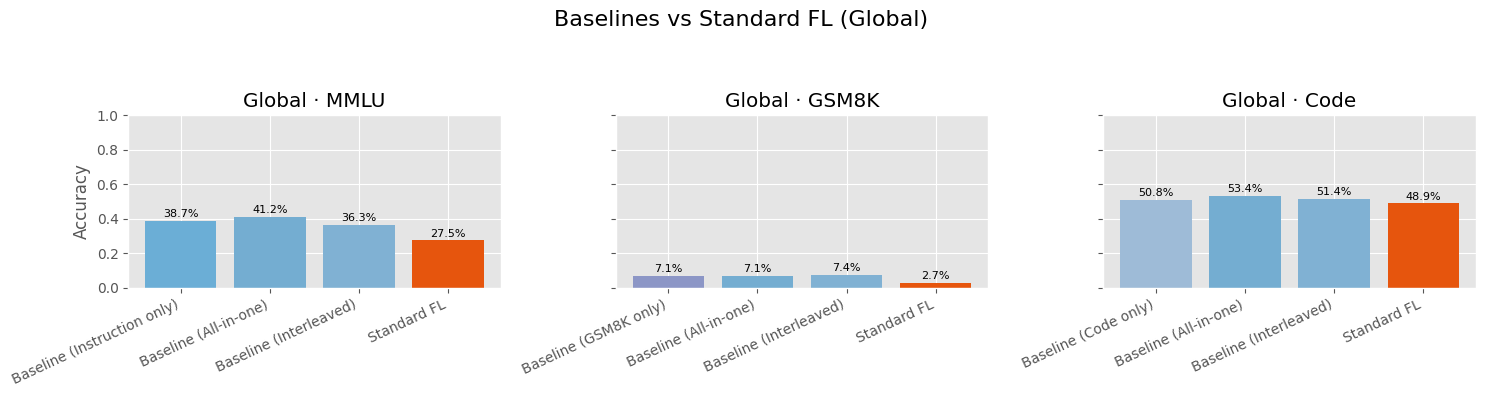

=== Baselines vs Standard FL — Clients ===


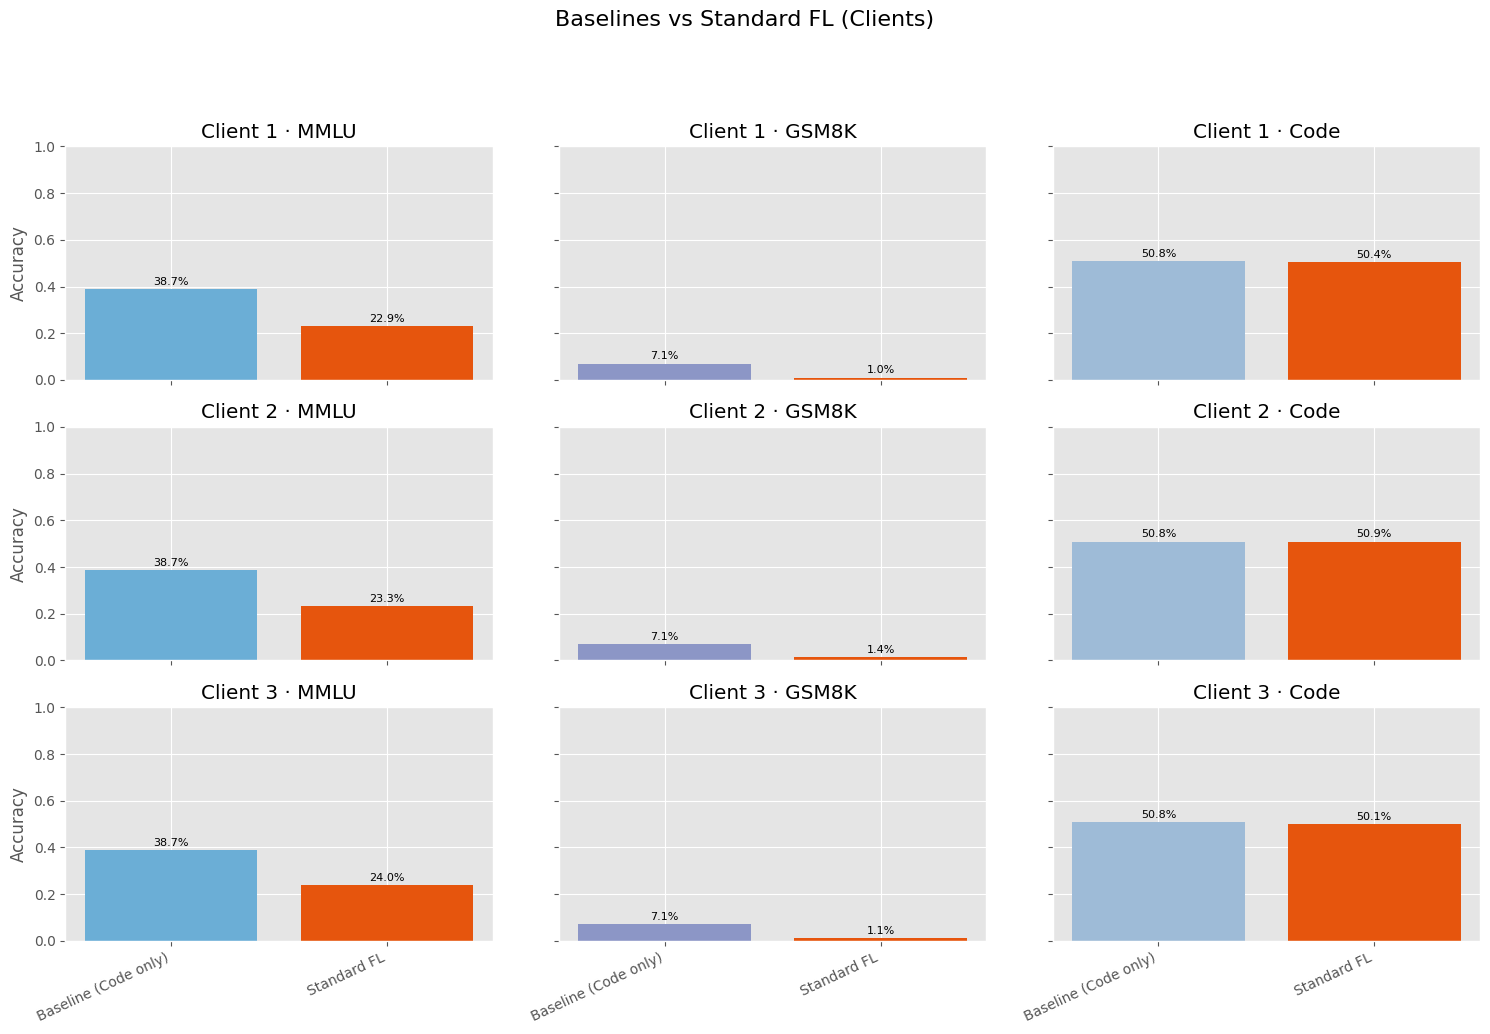

=== Baselines vs Standard FL vs Unlearn (+ shrink=0.5) — Global ===


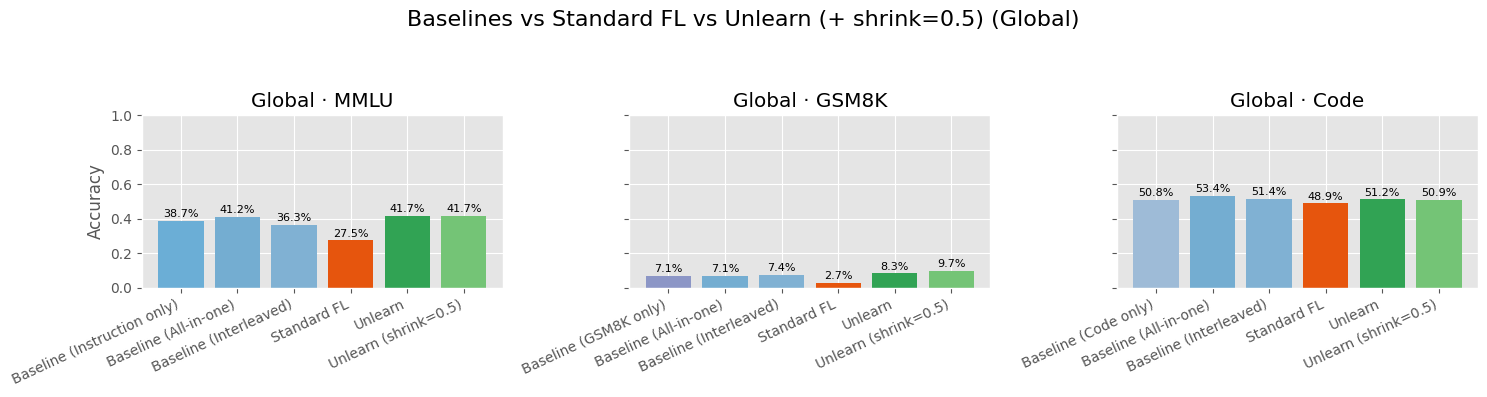

=== Baselines vs Standard FL vs Unlearn (+ shrink=0.5) — Clients ===


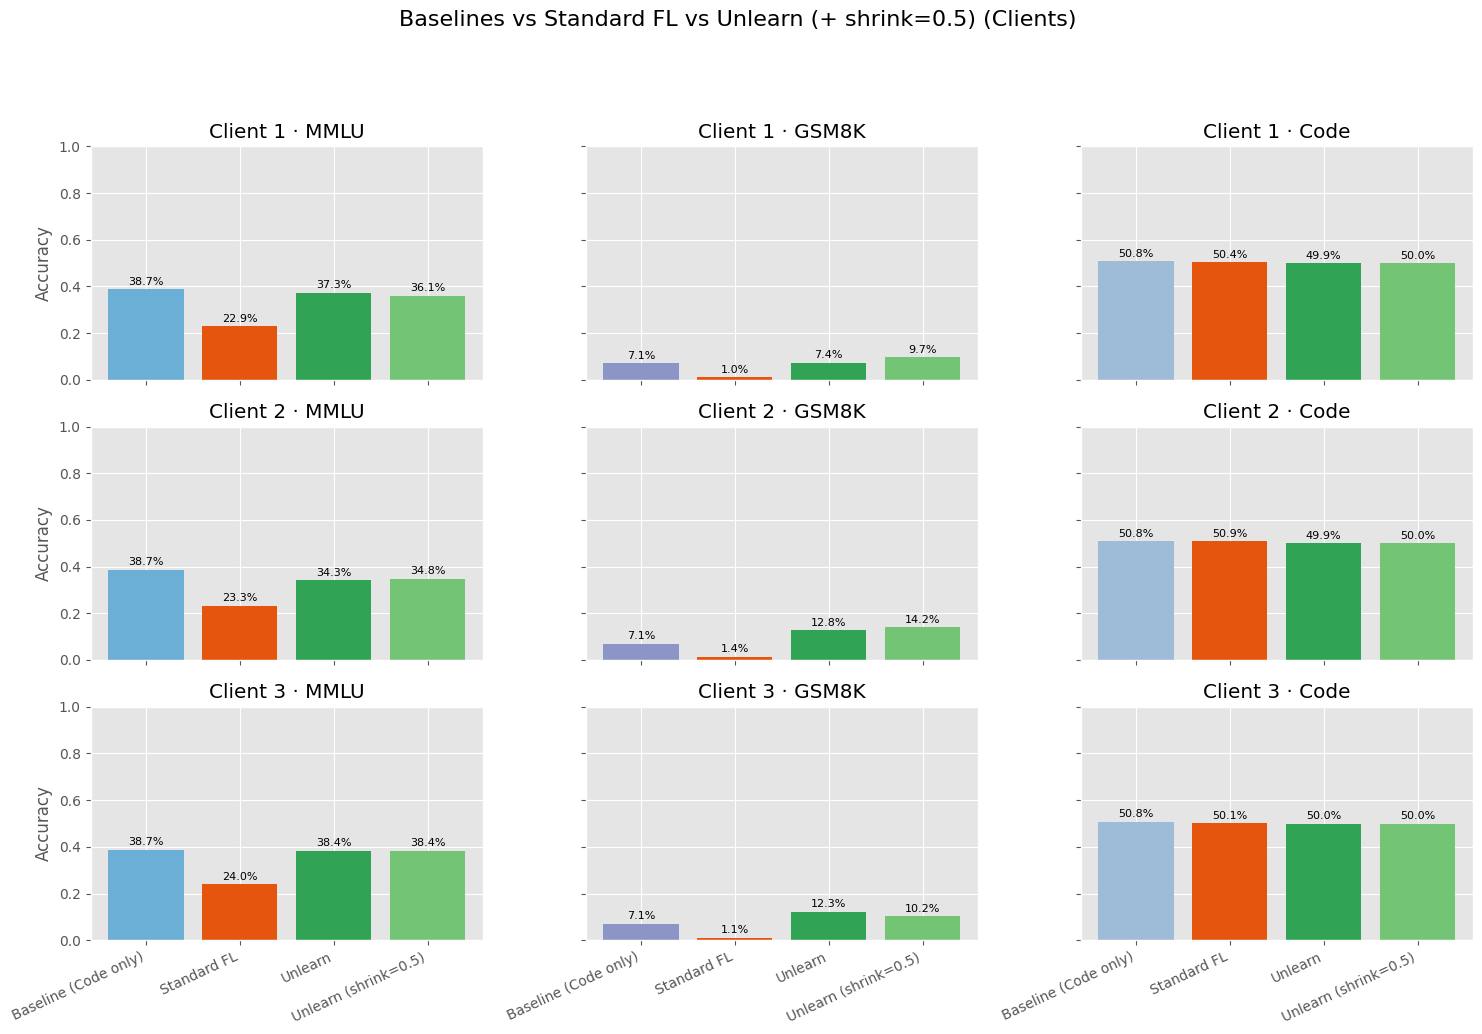

=== Baselines vs Standard FL vs Unlearn vs Unlearn (LOO variants) — Global ===


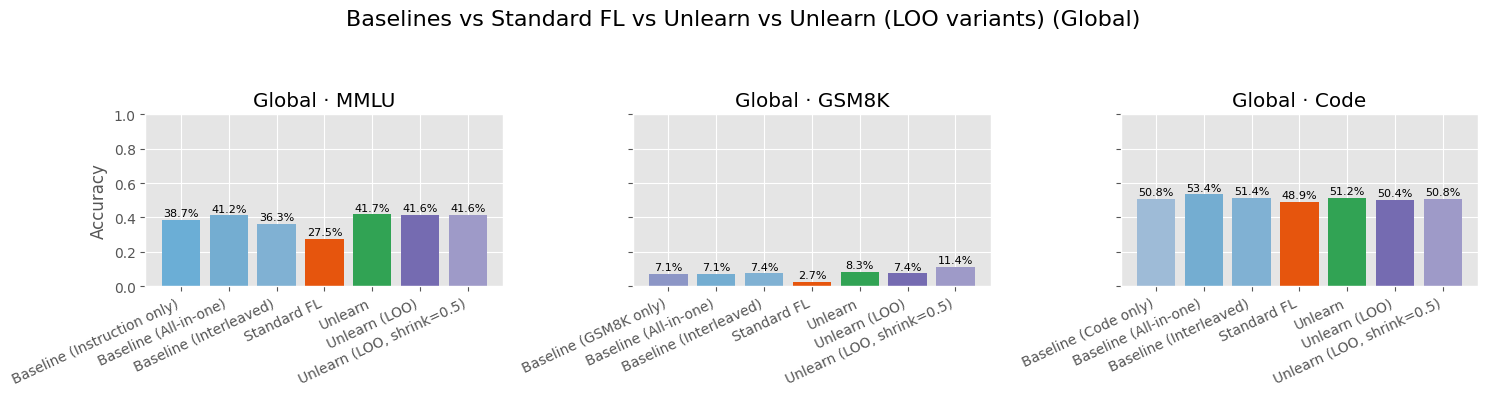

=== Baselines vs Standard FL vs Unlearn vs Unlearn (LOO variants) — Clients ===


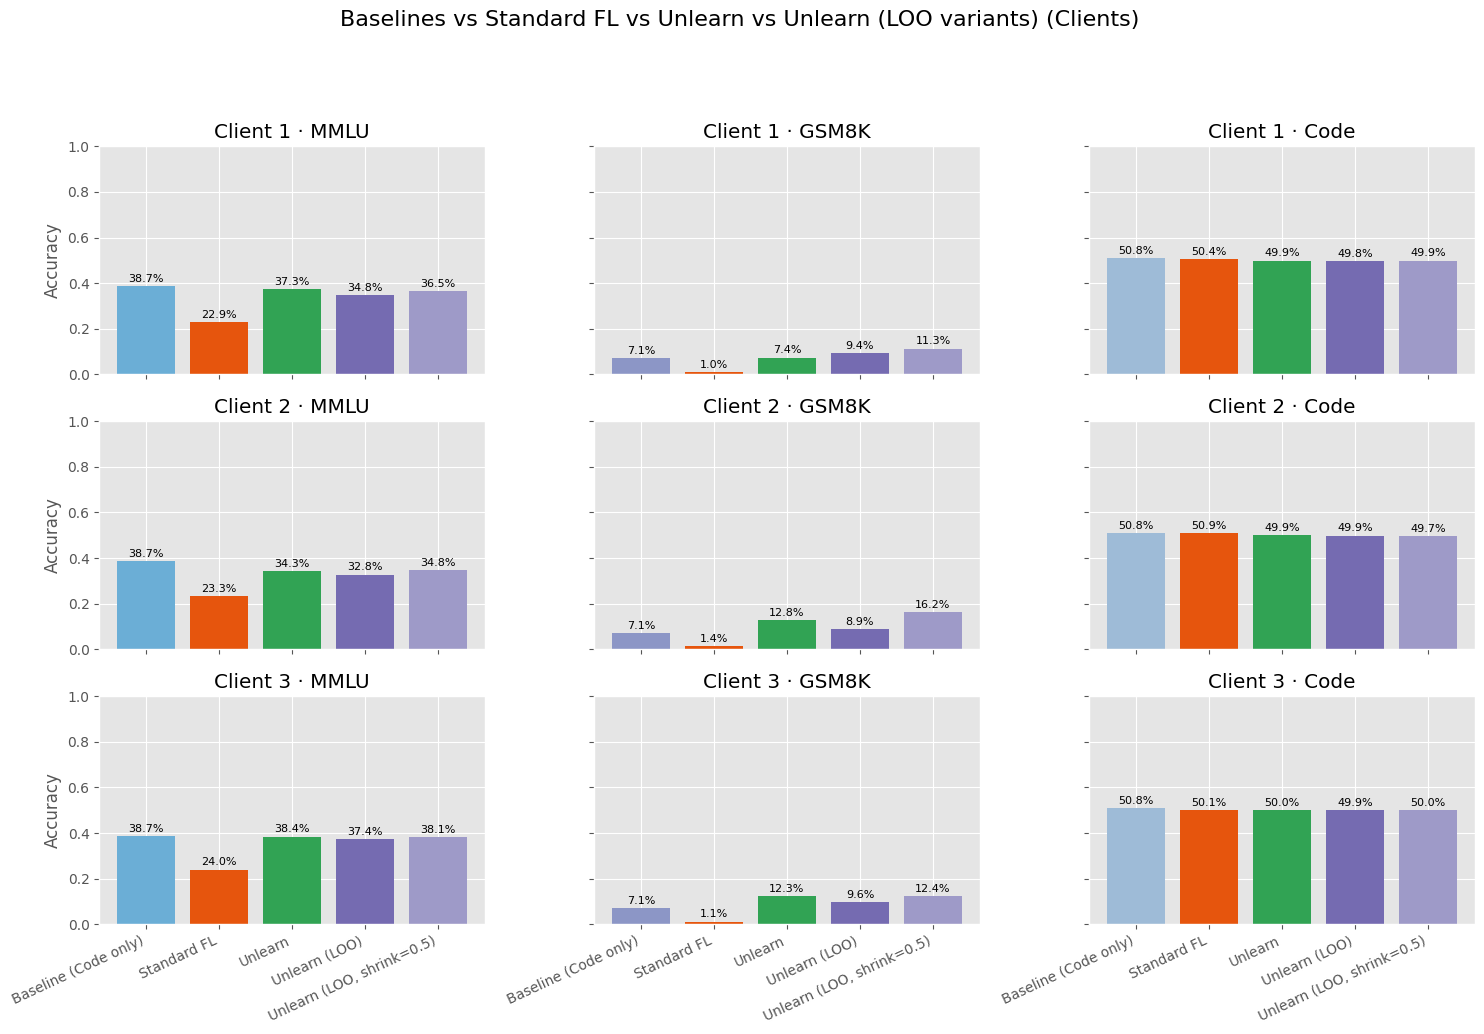

In [134]:

# === Baseline vs FL variant comparisons ===

DEFAULT_BASELINE_COLOR_BY_BENCH = {
    'mmlu': '#888888',
    'gsm8k': '#b0b0b0',
    'code': '#cccccc',
}
BASELINE_COLOR_BY_BENCH = DEFAULT_BASELINE_COLOR_BY_BENCH.copy()
BASELINE_COLOR_BY_BENCH.update(globals().get('BASELINE_COLOR_BY_BENCH', {}))

DEFAULT_GLOBAL_VARIANT_COLORS = {
    'Global · Standard FL': '#e6550d',
    'Global · Unlearn': '#31a354',
    'Global · Unlearn (shrink=0.5)': '#74c476',
    'Global · Unlearn (LOO)': '#756bb1',
    'Global · Unlearn (LOO, shrink=0.5)': '#9e9ac8',
}
GLOBAL_VARIANT_COLORS = DEFAULT_GLOBAL_VARIANT_COLORS.copy()
GLOBAL_VARIANT_COLORS.update(globals().get('GLOBAL_VARIANT_COLORS', {}))

DEFAULT_VARIANT_COLORS = {
    'Standard': '#e6550d',
    'Unlearn': '#31a354',
    'Unlearn (shrink=0.5)': '#74c476',
    'Unlearn (LOO)': '#756bb1',
    'Unlearn (LOO, shrink=0.5)': '#9e9ac8',
}
VARIANT_COLORS = DEFAULT_VARIANT_COLORS.copy()
VARIANT_COLORS.update(globals().get('VARIANT_COLORS', {}))

BASELINE_CLUSTER_COLORS = {
    'instruction only': '#6baed6',
    'all in one': '#74add1',
    'all-in-one': '#74add1',
    'interleaved': '#80b1d3',
    'gsm8k': '#8c96c6',
    'code only': '#9ebbd7',
    'code-only': '#9ebbd7',
}

VARIANT_CLUSTER_COLORS = {
    'Global · Standard FL': '#e6550d',
    'Global · Standard': '#e6550d',
    'Standard FL': '#e6550d',
    'Standard': '#e6550d',
    'Global · Unlearn': '#31a354',
    'Unlearn': '#31a354',
    'Global · Unlearn (shrink=0.5)': '#74c476',
    'Unlearn (shrink=0.5)': '#74c476',
    'Global · Unlearn (LOO)': '#756bb1',
    'Unlearn (LOO)': '#756bb1',
    'Global · Unlearn (LOO, shrink=0.5)': '#9e9ac8',
    'Unlearn (LOO, shrink=0.5)': '#9e9ac8',
}

BASELINE_GENERIC_KEYS = {'all_in_one', 'interleaved_all_in_one'}


def _spec_applicable_to_benchmark(benchmark_norm: str, spec: dict) -> bool:
    if spec.get('scope') != 'baseline':
        return True
    raw_benchmark = spec.get('benchmark_raw')
    if not raw_benchmark:
        return True
    if raw_benchmark in BASELINE_GENERIC_KEYS:
        return True
    target = SINGLE_TASK_BASELINE_TARGETS.get(raw_benchmark)
    if target:
        return target == benchmark_norm
    normalized = BENCHMARK_NORMALIZATION.get(raw_benchmark, raw_benchmark)
    return normalized == benchmark_norm


def _find_global_spec_for_label(label: str):
    for candidate_label, spec in GLOBAL_COLUMN_SPECS:
        if candidate_label == label:
            return spec
    return None


def _shorten_label(label: str) -> str:
    return label.replace('Global · ', '').strip()


def _get_baseline_color(base_label: str, bench: str):
    normalized = base_label.replace('Global ·', '').lower()
    for token, color in BASELINE_CLUSTER_COLORS.items():
        if token in normalized:
            return color
    return BASELINE_COLOR_BY_BENCH.get(bench, '#7f7f7f')


def _get_global_variant_color(variant_label: str):
    if variant_label in VARIANT_CLUSTER_COLORS:
        return VARIANT_CLUSTER_COLORS[variant_label]
    return GLOBAL_VARIANT_COLORS.get(variant_label, '#7f7f7f')


def _get_client_variant_color(display_label: str, variant_name: str):
    for key in (
        display_label,
        f'Global · {display_label}',
        f'Global · {variant_name}',
        variant_name,
    ):
        if key in VARIANT_CLUSTER_COLORS:
            return VARIANT_CLUSTER_COLORS[key]
    if variant_name in VARIANT_COLORS:
        return VARIANT_COLORS[variant_name]
    return GLOBAL_VARIANT_COLORS.get(f'Global · {variant_name}', '#7f7f7f')


def _is_unique_baseline_for(benchmark_norm: str, spec: dict) -> bool:
    raw_benchmark = spec.get('benchmark_raw')
    if not raw_benchmark or raw_benchmark in BASELINE_GENERIC_KEYS:
        return False
    target = SINGLE_TASK_BASELINE_TARGETS.get(raw_benchmark)
    if target:
        return target == benchmark_norm
    normalized = BENCHMARK_NORMALIZATION.get(raw_benchmark, raw_benchmark)
    return normalized == benchmark_norm


def _sanitize_value(value):
    if value is None:
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def _render_bar_panel(ax, series, title: str, show_ylabel: bool = False, show_xticklabels: bool = True):
    if not series:
        ax.set_title(title)
        ax.set_ylim(0, 1.0)
        if show_ylabel:
            ax.set_ylabel('Accuracy')
        ax.set_xticks([])
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', color='gray', fontsize=10)
        return

    positions = np.arange(len(series))
    values = [_sanitize_value(item['value']) for item in series]
    heights = [0 if np.isnan(val) else val for val in values]
    colors = [item['color'] for item in series]
    displays = [item['display'] for item in series]

    ax.bar(positions, heights, color=colors)
    ax.set_ylim(0, 1.0)
    if show_ylabel:
        ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.set_xticks(positions)
    if show_xticklabels:
        ax.set_xticklabels(displays, rotation=25, ha='right')
    else:
        ax.set_xticklabels([''] * len(displays))

    for xpos, value in zip(positions, values):
        if np.isnan(value):
            ax.text(xpos, 0.03, 'pending', ha='center', va='bottom', color='crimson', fontsize=9, fontweight='bold')
        else:
            ax.text(xpos, min(value + 0.01, 0.97), f"{value:.1%}", ha='center', va='bottom', fontsize=8)


def _collect_baseline_entries(family: str):
    benches = FAMILY_BENCHMARKS.get(family, [])
    entries = []
    baseline_specs = [
        (label, spec)
        for label, spec in GLOBAL_COLUMN_SPECS
        if spec.get('scope') == 'baseline'
    ]
    for bench in benches:
        bench_baselines = []
        for label, spec in baseline_specs:
            if _spec_applicable_to_benchmark(bench, spec):
                bench_baselines.append((label, spec))
        if bench_baselines:
            entries.append({
                'bench': bench,
                'bench_label': BENCHMARK_LABELS.get(bench, bench),
                'baseline_specs': bench_baselines
            })
    return entries


def _plot_global_baseline_vs_variants(family: str, entries: list, variant_labels, title: str):
    if not entries:
        print(f'No baselines available for {family}.')
        return

    fig, axes = plt.subplots(1, len(entries), figsize=(5 * len(entries), 4), sharey=True)
    if len(entries) == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=16)

    for idx, (ax, entry) in enumerate(zip(axes, entries)):
        bench = entry['bench']
        bench_label = entry['bench_label']
        series = []
        for base_label, base_spec in entry['baseline_specs']:
            base_val = fetch_metric(family, bench, base_spec)
            series.append({
                'label': base_label,
                'display': _shorten_label(base_label),
                'value': base_val,
                'color': _get_baseline_color(base_label, bench)
            })
        for variant_label in variant_labels:
            spec = _find_global_spec_for_label(variant_label)
            if spec is None:
                continue
            val = fetch_metric(family, bench, spec)
            series.append({
                'label': variant_label,
                'display': _shorten_label(variant_label),
                'value': val,
                'color': _get_global_variant_color(variant_label)
            })
        _render_bar_panel(
            ax,
            series,
            f'Global · {bench_label}',
            show_ylabel=(idx == 0),
            show_xticklabels=True
        )

    plt.tight_layout(rect=(0, 0, 1, 0.9))
    plt.show()


def _plot_client_baseline_vs_variants(family: str, entries: list, client_variants, title: str):
    if not entries:
        print(f'No baselines available for {family}.')
        return

    rows = len(CLIENT_IDS)
    cols = len(entries)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows), sharex=True, sharey='row')
    if rows == 1:
        axes = np.array([axes])
    if cols == 1:
        axes = axes.reshape(rows, 1)
    fig.suptitle(title, fontsize=16)

    for row, cid in enumerate(CLIENT_IDS):
        for col, entry in enumerate(entries):
            ax = axes[row][col]
            bench = entry['bench']
            bench_label = entry['bench_label']
            client_baselines = [
                item for item in entry['baseline_specs']
                if _is_unique_baseline_for(bench, item[1])
            ]
            if not client_baselines:
                client_baselines = entry['baseline_specs']
            series = []
            for base_label, base_spec in client_baselines:
                base_val = fetch_metric(family, bench, base_spec)
                series.append({
                    'label': base_label,
                    'display': _shorten_label(base_label),
                    'value': base_val,
                    'color': _get_baseline_color(base_label, bench)
                })
            for display_label, variant_name in client_variants:
                val = fetch_metric(family, bench, {
                    'scope': 'client',
                    'variant': variant_name,
                    'client': cid
                })
                series.append({
                    'label': display_label,
                    'display': display_label,
                    'value': val,
                    'color': _get_client_variant_color(display_label, variant_name)
                })
            _render_bar_panel(
                ax,
                series,
                f"{CLIENT_TITLES[row]} · {bench_label}",
                show_ylabel=(col == 0),
                show_xticklabels=(row == rows - 1)
            )

    plt.tight_layout(rect=(0, 0, 1, 0.92))
    plt.show()


family = 'LLaMA 2'
entries = _collect_baseline_entries(family)

comparison_configs = [
    {
        'title': 'Baselines vs Standard FL',
        'global_variants': ['Global · Standard FL'],
        'client_variants': [('Standard FL', 'Standard')]
    },
    {
        'title': 'Baselines vs Standard FL vs Unlearn (+ shrink=0.5)',
        'global_variants': ['Global · Standard FL', 'Global · Unlearn', 'Global · Unlearn (shrink=0.5)'],
        'client_variants': [
            ('Standard FL', 'Standard'),
            ('Unlearn', 'Unlearn'),
            ('Unlearn (shrink=0.5)', 'Unlearn (shrink=0.5)')
        ]
    },
    {
        'title': 'Baselines vs Standard FL vs Unlearn vs Unlearn (LOO variants)',
        'global_variants': [
            'Global · Standard FL',
            'Global · Unlearn',
            'Global · Unlearn (LOO)',
            'Global · Unlearn (LOO, shrink=0.5)'
        ],
        'client_variants': [
            ('Standard FL', 'Standard'),
            ('Unlearn', 'Unlearn'),
            ('Unlearn (LOO)', 'Unlearn (LOO)'),
            ('Unlearn (LOO, shrink=0.5)', 'Unlearn (LOO, shrink=0.5)')
        ]
    }
]

for config in comparison_configs:
    print(f"=== {config['title']} — Global ===")
    _plot_global_baseline_vs_variants(
        family,
        entries,
        config['global_variants'],
        f"{config['title']} (Global)"
    )
    print(f"=== {config['title']} — Clients ===")
    _plot_client_baseline_vs_variants(
        family,
        entries,
        config['client_variants'],
        f"{config['title']} (Clients)"
    )



In [135]:
# Legacy plotting helpers have been merged into the cell above.


## 4. LOO vs. standard UNLEARN (LLaMA 2)


/tmp/ipykernel_1499399/716604005.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_global.set_xticklabels(global_labels, rotation=25, ha='right')
/tmp/ipykernel_1499399/716604005.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_clients.set_xticklabels(client_labels, rotation=25, ha='right')
/tmp/ipykernel_1499399/716604005.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_global.set_xticklabels(global_labels, rotation=25, ha='right')
/tmp/ipykernel_1499399/716604005.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_clients.set_xticklabels(client_labels, rotation=25, ha='right')
/tmp/ipykernel_1499399/716604005.py:25: UserWarning: s

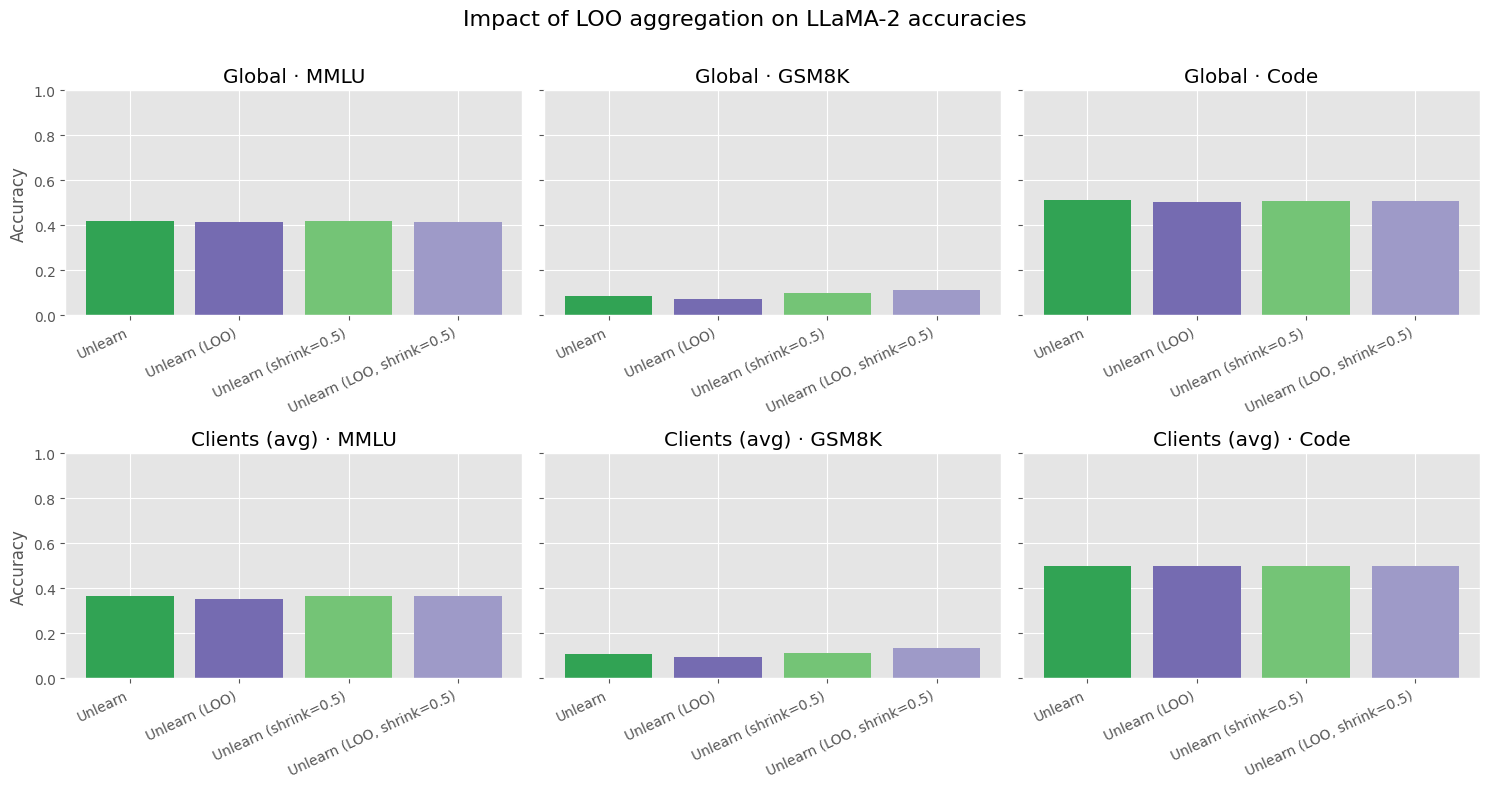

In [136]:
# === LOO vs. standard UNLEARN comparison (global + averaged clients) ===
loo_variants = [
    ('Unlearn', 'Unlearn'),
    ('Unlearn (LOO)', 'Unlearn (LOO)'),
    ('Unlearn (shrink=0.5)', 'Unlearn (shrink=0.5)'),
    ('Unlearn (LOO, shrink=0.5)', 'Unlearn (LOO, shrink=0.5)')
]
benchmarks = FAMILY_BENCHMARKS['LLaMA 2']
variant_colors = {label: VARIANT_COLORS[label] for label, _ in loo_variants}
fig, axes = plt.subplots(2, len(benchmarks), figsize=(5 * len(benchmarks), 8), sharey='row')
fig.suptitle('Impact of LOO aggregation on LLaMA-2 accuracies', fontsize=16)
for b_idx, benchmark in enumerate(benchmarks):
    ax_global = axes[0][b_idx]
    ax_clients = axes[1][b_idx]
    global_vals = []
    global_labels = []
    for label, variant_name in loo_variants:
        score = fetch_metric('LLaMA 2', benchmark, {'scope': 'global', 'variant': variant_name})
        global_vals.append(score)
        global_labels.append(label)
    ax_global.bar(global_labels, global_vals, color=[variant_colors[lbl] for lbl in global_labels])
    ax_global.set_title(f"Global · {BENCHMARK_LABELS[benchmark]}")
    ax_global.set_ylim(0, 1)
    ax_global.set_ylabel('Accuracy' if b_idx == 0 else '')
    ax_global.set_xticklabels(global_labels, rotation=25, ha='right')
    client_vals = []
    client_labels = []
    for label, variant_name in loo_variants:
        per_client = []
        for cid in CLIENT_IDS:
            score = fetch_metric('LLaMA 2', benchmark, {
                'scope': 'client',
                'variant': variant_name,
                'client': cid,
            })
            if not np.isnan(score):
                per_client.append(score)
        client_vals.append(np.mean(per_client) if per_client else np.nan)
        client_labels.append(label)
    ax_clients.bar(client_labels, client_vals, color=[variant_colors[lbl] for lbl in client_labels])
    ax_clients.set_title(f"Clients (avg) · {BENCHMARK_LABELS[benchmark]}")
    ax_clients.set_ylim(0, 1)
    ax_clients.set_ylabel('Accuracy' if b_idx == 0 else '')
    ax_clients.set_xticklabels(client_labels, rotation=25, ha='right')
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


## 5. LLaMA-2 bank-per-client UNLEARN results

The training job launched with `yamls/full/llama2_composite_meta3_unlearn_bank_perclient.yaml` plus the follow-up evaluations in `scripts/run_llama_bank_perclient_followups.sh` drop their metrics into `results_full/global/llama2_unlearn_bank_perclient/` and `results_full/clients/llama2_unlearn_bank_perclient/`. Each eval script also emits summaries under `eval_result/accuracies_ckpts_full_llama2_composite_meta3_unlearn_bank_perclient*.json`, so the ingestion code above already parsed the new run into `records_df`. The cell below isolates that variant and plots how it compares with the prior standard/UNLEARN/UNLEARN-LOO checkpoints for both the global model and the client adapters.

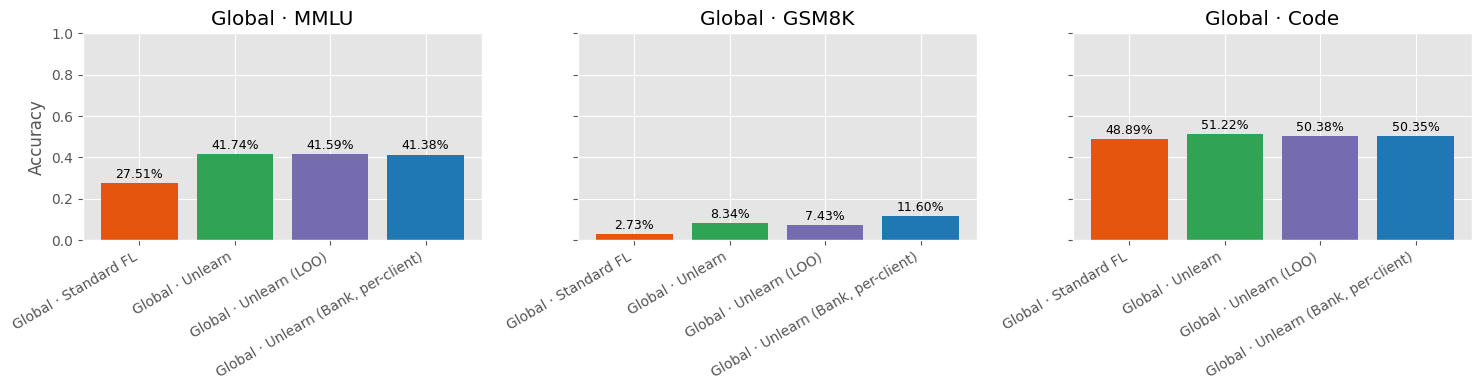

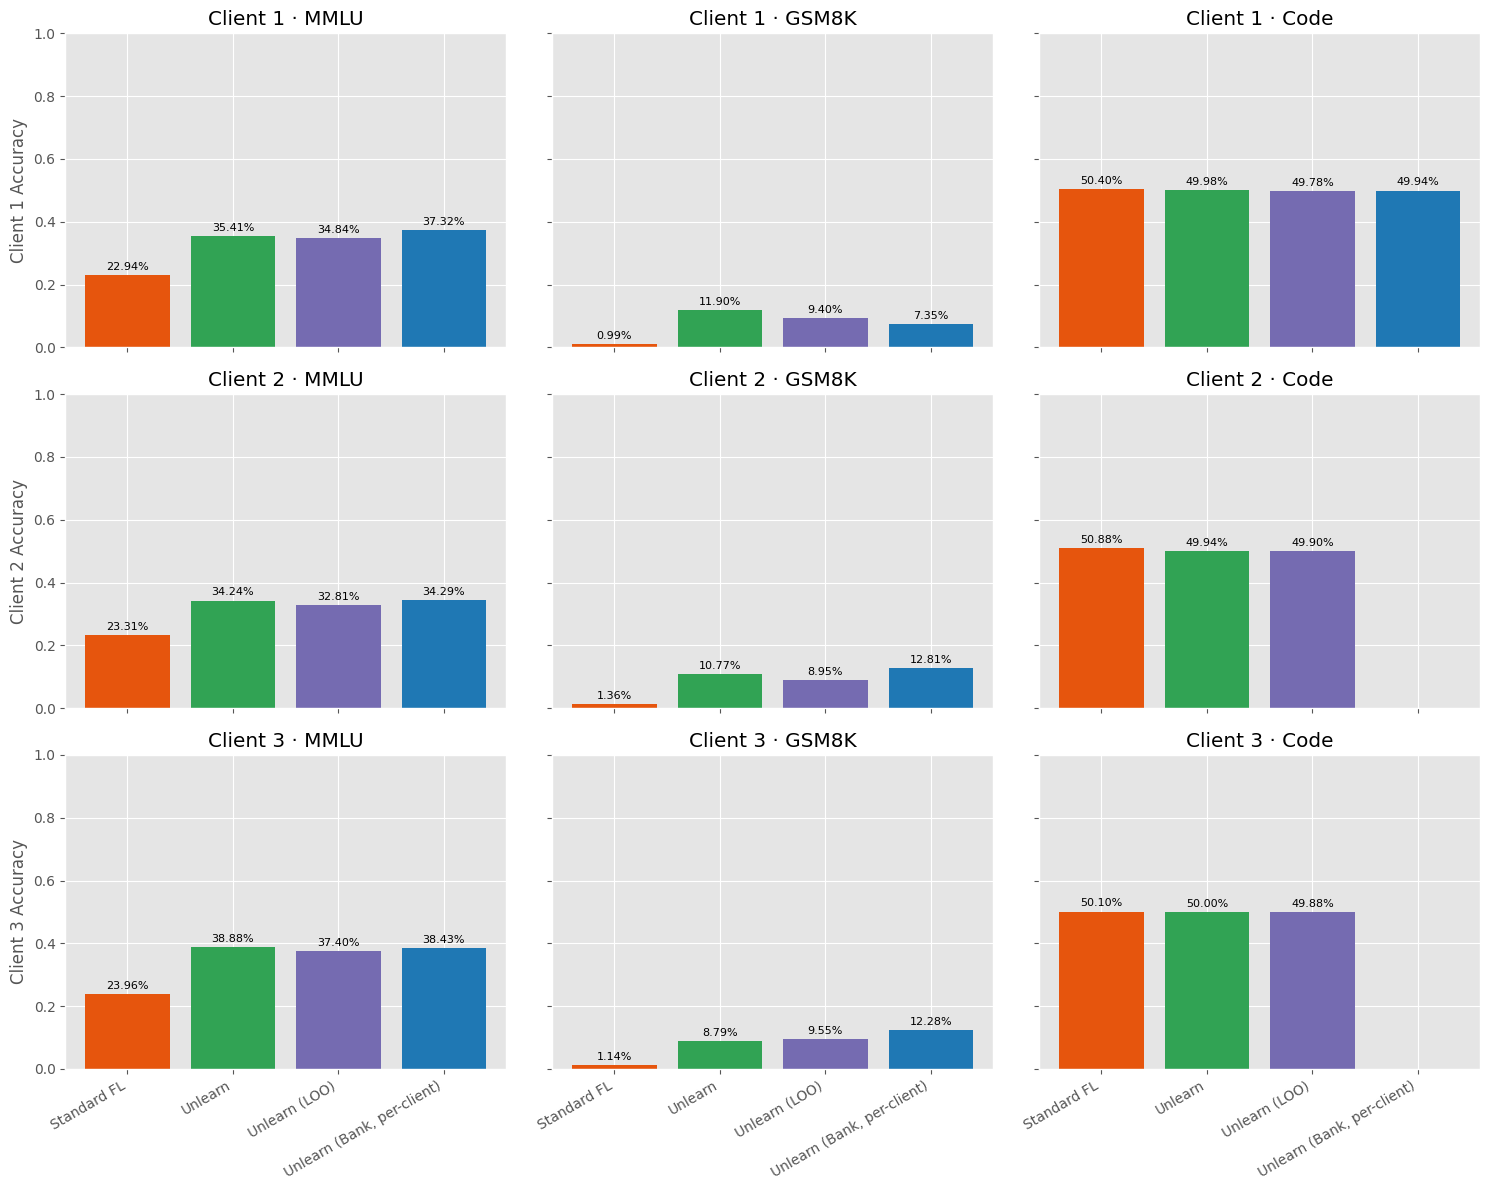

In [137]:
# === Bank-per-client UNLEARN vs prior LLaMA-2 runs ===
BANK_MODEL_KEY = 'llama2_composite_meta3_unlearn_bank_perclient'
if 'records_df' not in globals():
    raise RuntimeError('Run Section 1 to populate records_df before plotting the bank-per-client results.')
if BANK_MODEL_KEY not in set(records_df['model_key']):
    print('No evaluation artifacts for the bank-per-client run were found in eval_result/.')
else:
    bank_color = '#1f78b4'
    for palette_name in ('GLOBAL_VARIANT_COLORS', 'VARIANT_CLUSTER_COLORS'):
        palette = globals().get(palette_name)
        if palette is not None:
            palette.setdefault('Global · Unlearn (Bank, per-client)', bank_color)
            palette.setdefault('Unlearn (Bank, per-client)', bank_color)
    variant_palette = globals().get('VARIANT_COLORS')
    if variant_palette is not None:
        variant_palette.setdefault('Unlearn (Bank, per-client)', bank_color)

    llama_records = records_df[
        (records_df['model_family'] == 'LLaMA 2') &
        (records_df['scale'] == 'full')
    ].copy()
    llama_records['variant_plus'] = np.where(
        llama_records['model_key'] == BANK_MODEL_KEY,
        'Unlearn (Bank, per-client)',
        llama_records['variant']
    )

    def _lookup_metric(scope: str, bench: str, variant_label: str, client: str = None) -> float:
        mask = (
            (llama_records['scope'] == scope) &
            (llama_records['benchmark_norm'] == bench) &
            (llama_records['variant_plus'] == variant_label)
        )
        if client is not None:
            mask &= (llama_records['client'] == client)
        subset = llama_records[mask]
        return subset['weighted_accuracy'].mean() if not subset.empty else np.nan

    def _safe_global_color(label: str) -> str:
        if '_get_global_variant_color' in globals():
            return _get_global_variant_color(label)
        return globals().get('GLOBAL_VARIANT_COLORS', {}).get(label, '#7f7f7f')

    def _safe_client_color(display_label: str, variant_name: str) -> str:
        if '_get_client_variant_color' in globals():
            return _get_client_variant_color(display_label, variant_name)
        palette = globals().get('VARIANT_COLORS', {})
        if variant_name in palette:
            return palette[variant_name]
        return globals().get('GLOBAL_VARIANT_COLORS', {}).get(f'Global · {variant_name}', '#7f7f7f')

    bench_order = FAMILY_BENCHMARKS['LLaMA 2']
    bench_labels = [BENCHMARK_LABELS.get(b, b) for b in bench_order]
    global_variants = [
        ('Global · Standard FL', 'Standard'),
        ('Global · Unlearn', 'Unlearn'),
        ('Global · Unlearn (LOO)', 'Unlearn (LOO)'),
        ('Global · Unlearn (Bank, per-client)', 'Unlearn (Bank, per-client)'),
    ]
    client_variants = [
        ('Standard FL', 'Standard'),
        ('Unlearn', 'Unlearn'),
        ('Unlearn (LOO)', 'Unlearn (LOO)'),
        ('Unlearn (Bank, per-client)', 'Unlearn (Bank, per-client)'),
    ]

    # --- Global model comparison ---
    global_scores = {display: {} for display, _ in global_variants}
    fig, axes = plt.subplots(1, len(bench_order), figsize=(5 * len(bench_order), 4), sharey=True)
    if len(bench_order) == 1:
        axes = [axes]
    for ax, bench, bench_label in zip(axes, bench_order, bench_labels):
        labels = [display for display, _ in global_variants]
        values = []
        for display, variant_name in global_variants:
            score = _lookup_metric('global', bench, variant_name)
            global_scores[display][bench_label] = score
            values.append(score)
        colors = [_safe_global_color(lbl) for lbl in labels]
        positions = np.arange(len(labels))
        ax.bar(positions, values, color=colors)
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=30, ha='right')
        ax.set_ylim(0, 1.0)
        ax.set_ylabel('Accuracy' if ax is axes[0] else '')
        ax.set_title(f'Global · {bench_label}')
        for xpos, val in zip(positions, values):
            if np.isnan(val):
                ax.text(xpos, 0.02, 'pending', ha='center', va='bottom', color='crimson', fontsize=9, fontweight='bold')
            else:
                ax.text(xpos, val + 0.01, f'{val:.2%}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # --- Client model comparison (per client & benchmark) ---
    client_fig, client_axes = plt.subplots(len(CLIENT_IDS), len(bench_order), figsize=(5 * len(bench_order), 4 * len(CLIENT_IDS)), sharex=True, sharey='row')
    if len(CLIENT_IDS) == 1:
        client_axes = np.array([client_axes])
    client_scores = {display: {} for display, _ in client_variants}
    for row, cid in enumerate(CLIENT_IDS):
        for col, (bench, bench_label) in enumerate(zip(bench_order, bench_labels)):
            ax = client_axes[row][col]
            positions = np.arange(len(client_variants))
            values = []
            colors = []
            for display, variant_name in client_variants:
                score = _lookup_metric('client', bench, variant_name, client=cid)
                values.append(score)
                colors.append(_safe_client_color(display, variant_name))
                bench_scores = client_scores.setdefault(display, {}).setdefault(bench_label, [])
                if not np.isnan(score):
                    bench_scores.append(score)
            ax.bar(positions, values, color=colors)
            ax.set_xticks(positions)
            ax.set_xticklabels([disp for disp, _ in client_variants], rotation=30, ha='right')
            ax.set_ylim(0, 1.0)
            if col == 0:
                ax.set_ylabel(f'{CLIENT_TITLES[row]} Accuracy')
            ax.set_title(f'{CLIENT_TITLES[row]} · {bench_label}')
            for xpos, val in zip(positions, values):
                if not np.isnan(val):
                    ax.text(xpos, val + 0.01, f'{val:.2%}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()

    # # --- Summary tables ---
    # global_summary = pd.DataFrame([
    #     {'Variant': display, **scores}
    #     for display, scores in global_scores.items()
    # ])
    # client_summary = []
    # for display, bench_scores in client_scores.items():
    #     row = {'Variant': display}
    #     for bench_label in bench_labels:
    #         vals = bench_scores.get(bench_label, [])
    #         row[bench_label] = float(np.mean(vals)) if vals else np.nan
    #     client_summary.append(row)
    # client_summary = pd.DataFrame(client_summary)
    # print('Global accuracy comparison (higher is better):')
    # display(global_summary.set_index('Variant'))
    # print('Client accuracy comparison (mean over available clients):')
    # display(client_summary.set_index('Variant'))
    # if global_summary.isna().any().any() or client_summary.isna().any().any():
    #     print('Note: NaN entries indicate that the corresponding eval_result/*.json artifact has not been produced yet.')
